# Logistic Regression Model

In [7]:
from logistic_regression_utils import *
import numpy as np
from utils import *

D, L = load("train_data.txt")
(D_training, L_training), (D_eval, L_eval) = split_db_2to1(D, L)
pi_target = 0.1

In [8]:

lambdas = np.logspace(-4, 2, 13)
DCFs = []

for l in lambdas:
    x, pi_emp = train_log_model(D_training, L_training, l)
    acc, minDCF, actDCF = evaluate_log_model(x, D_eval, L_eval, pi_emp, pi_target)
    DCFs.append((minDCF, actDCF))

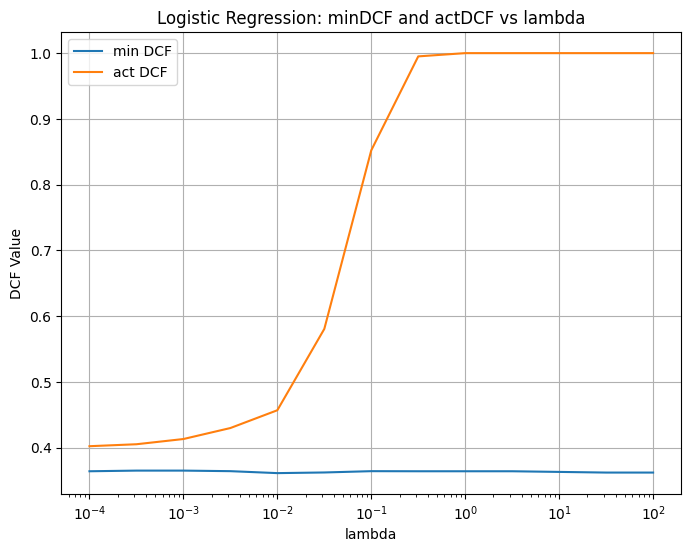

In [9]:
import matplotlib.pyplot as plt

min_dcfs = [dcf[0] for dcf in DCFs]
act_dcfs = [dcf[1] for dcf in DCFs]

plt.figure(figsize=(8, 6))

plt.plot(lambdas, min_dcfs, label='min DCF')
plt.plot(lambdas, act_dcfs, label='act DCF')

plt.xscale('log', base=10) 

plt.xlabel('lambda')
plt.ylabel('DCF Value')
plt.title('Logistic Regression: minDCF and actDCF vs lambda')
plt.legend()
plt.grid(True)
plt.show()

### Training using only 50 samples
The objective is to understand the effect of the number of samples over regularization 

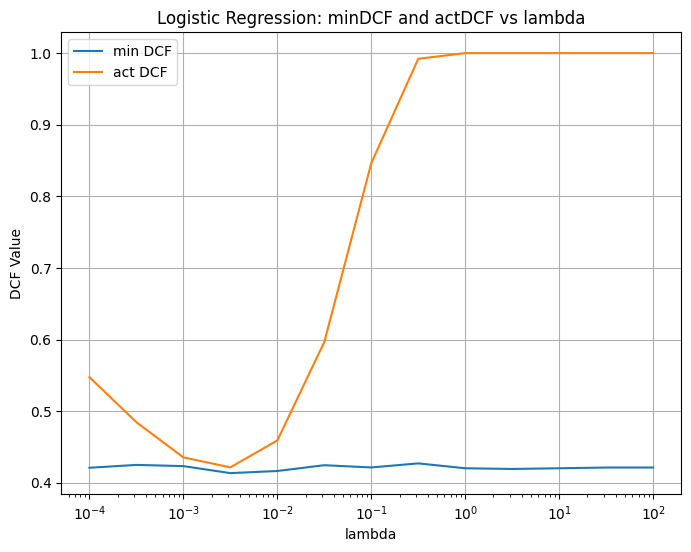

In [10]:
D_training_50 = D_training[:, :50]
L_training_50 = L_training[:50]

DCFs = []

for l in lambdas:
    x, pi_emp = train_log_model(D_training_50, L_training_50, l)
    acc, minDCF, actDCF = evaluate_log_model(x, D_eval, L_eval, pi_emp, pi_target)
    DCFs.append((minDCF, actDCF))

min_dcfs = [dcf[0] for dcf in DCFs]
act_dcfs = [dcf[1] for dcf in DCFs]

plt.figure(figsize=(8, 6))

plt.plot(lambdas, min_dcfs, label='min DCF')
plt.plot(lambdas, act_dcfs, label='act DCF')

plt.xscale('log', base=10) 

plt.xlabel('lambda')
plt.ylabel('DCF Value')
plt.title('Logistic Regression: minDCF and actDCF vs lambda')
plt.legend()
plt.grid(True)
plt.show()

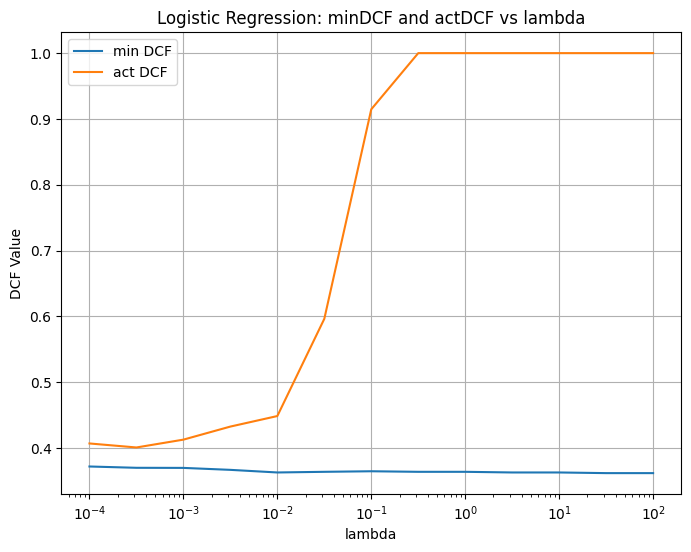

In [11]:
DCFs = []

for l in lambdas:
    x, pi_emp = train_log_model_weighted(D_training, L_training, l, pi_target)
    acc, minDCF, actDCF = evaluate_log_model(x, D_eval, L_eval, pi_target, pi_target)
    DCFs.append((minDCF, actDCF))

min_dcfs = [dcf[0] for dcf in DCFs]
act_dcfs = [dcf[1] for dcf in DCFs]

plt.figure(figsize=(8, 6))

plt.plot(lambdas, min_dcfs, label='min DCF')
plt.plot(lambdas, act_dcfs, label='act DCF')

plt.xscale('log', base=10) 

plt.xlabel('lambda')
plt.ylabel('DCF Value')
plt.title('Logistic Regression: minDCF and actDCF vs lambda')
plt.legend()
plt.grid(True)
plt.show()